In [4]:
! pip install kaggle


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.2/173.2 kB 1.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.2/78.2 kB 4.0 MB/s eta 0:00:00a 0:00:01


# Dataset Downloading

In [8]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mkdir: /Users/pandukv/.kaggle: File exists


In [2]:
! kaggle competitions download -c dogs-vs-cats -f train.zip

 98%|███████████████████████████████████████ | 531M/543M [00:00<00:00, 1.37GB/s]
100%|████████████████████████████████████████| 543M/543M [00:00<00:00, 1.35GB/s]


# Copying images to training, validation, and test directories

In [10]:
import os, shutil, pathlib

original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("cats_vs_dogs_small")

def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname,
                            dst=dir / fname)

make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

# Building the model # #Instantiating a small convnet for dogs vs. cats classification

In [11]:


from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

2025-04-12 07:07:45.326836: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-04-12 07:07:45.326881: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-04-12 07:07:45.326894: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-04-12 07:07:45.327095: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-12 07:07:45.327300: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [12]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 89, 89, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 43, 43, 64)        0         
 g2D)                                                        

# Configuring the model for training

In [13]:

model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])


# Data preprocessing
Using image_dataset_from_directory to read images

In [47]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [15]:
import numpy as np
import tensorflow as tf
random_numbers = np.random.normal(size=(1000, 16))
dataset = tf.data.Dataset.from_tensor_slices(random_numbers)

In [16]:
for i, element in enumerate(dataset):
    print(element.shape)
    if i >= 2:
        break

(16,)
(16,)
(16,)


In [17]:
batched_dataset = dataset.batch(32)
for i, element in enumerate(batched_dataset):
    print(element.shape)
    if i >= 2:
        break

(32, 16)
(32, 16)
(32, 16)


In [18]:
reshaped_dataset = dataset.map(lambda x: tf.reshape(x, (4, 4)))
for i, element in enumerate(reshaped_dataset):
    print(element.shape)
    if i >= 2:
        break

(4, 4)
(4, 4)
(4, 4)


## Displaying the shapes of the data and labels yielded by the Dataset

In [20]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (32, 180, 180, 3)
labels batch shape: (32,)


# Fitting the model using a Dataset

In [22]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.x",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30
63/63 [==============================] - ETA: 0s - loss: 0.7225 - accuracy: 0.5540INFO:tensorflow:Assets written to: convnet_from_scratch.x/assets


INFO:tensorflow:Assets written to: convnet_from_scratch.x/assets


63/63 [==============================] - 23s 356ms/step - loss: 0.7225 - accuracy: 0.5540 - val_loss: 0.7449 - val_accuracy: 0.5180
Epoch 2/30
63/63 [==============================] - 19s 302ms/step - loss: 0.6782 - accuracy: 0.5905 - val_loss: 0.7585 - val_accuracy: 0.5840
Epoch 3/30
63/63 [==============================] - ETA: 0s - loss: 0.6394 - accuracy: 0.6510INFO:tensorflow:Assets written to: convnet_from_scratch.x/assets


INFO:tensorflow:Assets written to: convnet_from_scratch.x/assets


63/63 [==============================] - 28s 437ms/step - loss: 0.6394 - accuracy: 0.6510 - val_loss: 0.6392 - val_accuracy: 0.6020
Epoch 4/30
63/63 [==============================] - ETA: 0s - loss: 0.6033 - accuracy: 0.6935INFO:tensorflow:Assets written to: convnet_from_scratch.x/assets


INFO:tensorflow:Assets written to: convnet_from_scratch.x/assets


63/63 [==============================] - 23s 357ms/step - loss: 0.6033 - accuracy: 0.6935 - val_loss: 0.6045 - val_accuracy: 0.6850
Epoch 5/30
63/63 [==============================] - ETA: 0s - loss: 0.5550 - accuracy: 0.7200INFO:tensorflow:Assets written to: convnet_from_scratch.x/assets


INFO:tensorflow:Assets written to: convnet_from_scratch.x/assets


63/63 [==============================] - 24s 383ms/step - loss: 0.5550 - accuracy: 0.7200 - val_loss: 0.5776 - val_accuracy: 0.6760
Epoch 6/30
63/63 [==============================] - 20s 311ms/step - loss: 0.5186 - accuracy: 0.7395 - val_loss: 0.6371 - val_accuracy: 0.6930
Epoch 7/30
63/63 [==============================] - 19s 293ms/step - loss: 0.4709 - accuracy: 0.7770 - val_loss: 0.6141 - val_accuracy: 0.6720
Epoch 8/30
63/63 [==============================] - 19s 299ms/step - loss: 0.4203 - accuracy: 0.8140 - val_loss: 0.5909 - val_accuracy: 0.7340
Epoch 9/30
63/63 [==============================] - 20s 317ms/step - loss: 0.3680 - accuracy: 0.8380 - val_loss: 0.6055 - val_accuracy: 0.7330
Epoch 10/30
63/63 [==============================] - 19s 301ms/step - loss: 0.3248 - accuracy: 0.8630 - val_loss: 0.6497 - val_accuracy: 0.7490
Epoch 11/30
63/63 [==============================] - 23s 357ms/step - loss: 0.2536 - accuracy: 0.8900 - val_loss: 0.7660 - val_accuracy: 0.7020
Epoch 12

# Displaying curves of loss and accuracy during training

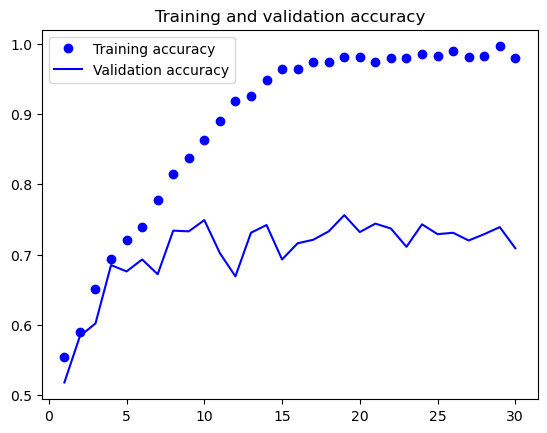

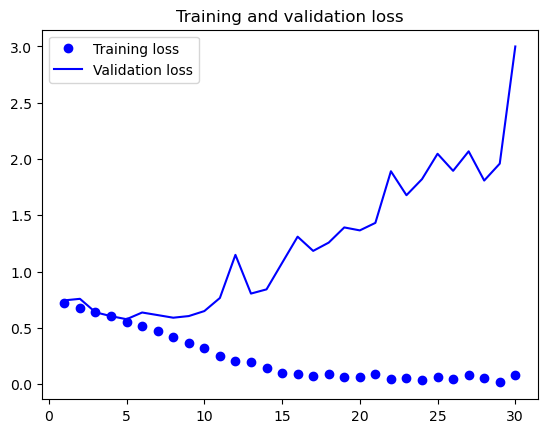

In [23]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

# Evaluating the model on the test set

In [25]:
test_model = keras.models.load_model("convnet_from_scratch.x")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

2025-04-12 07:34:05.629804: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


63/63 [==============================] - 5s 69ms/step - loss: 0.5854 - accuracy: 0.6925
Test accuracy: 0.692


# Leveraging a pretrained model
Feature extraction with a pretrained model,
   Instantiating the VGG16 convolutional base

In [26]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))

In [27]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 180, 180, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 180, 180, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 90, 90, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 90, 90, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 90, 90, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 45, 45, 128)       0     

# Fast feature extraction without data augmentation
Extracting the VGG16 features and corresponding labels

In [28]:
import numpy as np

def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels =  get_features_and_labels(train_dataset)
val_features, val_labels =  get_features_and_labels(validation_dataset)
test_features, test_labels =  get_features_and_labels(test_dataset)

2025-04-12 07:35:37.191107: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 457ms/step


2025-04-12 07:36:46.221763: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 49ms/step


In [29]:
train_features.shape

(2000, 5, 5, 512)

# Defining and training the densely connected classifier

In [31]:
inputs = keras.Input(shape=(5, 5, 512))
x = layers.Flatten()(inputs)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
      filepath="feature_extraction.x",
      save_best_only=True,
      monitor="val_loss")
]
history = model.fit(
    train_features, train_labels,
    epochs=20,
    validation_data=(val_features, val_labels),
    callbacks=callbacks)

Epoch 1/20


2025-04-12 07:40:15.072894: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


63/63 [==============================] - ETA: 0s - loss: 15.1368 - accuracy: 0.9220

2025-04-12 07:40:18.465472: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


INFO:tensorflow:Assets written to: feature_extraction.x/assets


INFO:tensorflow:Assets written to: feature_extraction.x/assets


63/63 [==============================] - 7s 87ms/step - loss: 15.1368 - accuracy: 0.9220 - val_loss: 3.3903 - val_accuracy: 0.9760
Epoch 2/20
63/63 [==============================] - 2s 27ms/step - loss: 3.1308 - accuracy: 0.9795 - val_loss: 9.9795 - val_accuracy: 0.9420
Epoch 3/20
62/63 [============================>.] - ETA: 0s - loss: 2.2145 - accuracy: 0.9854INFO:tensorflow:Assets written to: feature_extraction.x/assets


INFO:tensorflow:Assets written to: feature_extraction.x/assets


63/63 [==============================] - 4s 65ms/step - loss: 2.1967 - accuracy: 0.9855 - val_loss: 3.3291 - val_accuracy: 0.9800
Epoch 4/20
63/63 [==============================] - 2s 29ms/step - loss: 1.9945 - accuracy: 0.9850 - val_loss: 3.7892 - val_accuracy: 0.9780
Epoch 5/20
63/63 [==============================] - 2s 29ms/step - loss: 0.9663 - accuracy: 0.9930 - val_loss: 5.2064 - val_accuracy: 0.9750
Epoch 6/20
63/63 [==============================] - 2s 30ms/step - loss: 1.2766 - accuracy: 0.9910 - val_loss: 4.6795 - val_accuracy: 0.9740
Epoch 7/20
63/63 [==============================] - 2s 28ms/step - loss: 1.3432 - accuracy: 0.9905 - val_loss: 5.1009 - val_accuracy: 0.9760
Epoch 8/20
63/63 [==============================] - 2s 28ms/step - loss: 0.6694 - accuracy: 0.9970 - val_loss: 4.7188 - val_accuracy: 0.9760
Epoch 9/20
63/63 [==============================] - 2s 32ms/step - loss: 0.5085 - accuracy: 0.9950 - val_loss: 4.1530 - val_accuracy: 0.9800
Epoch 10/20
63/63 [=====

# Plotting the results

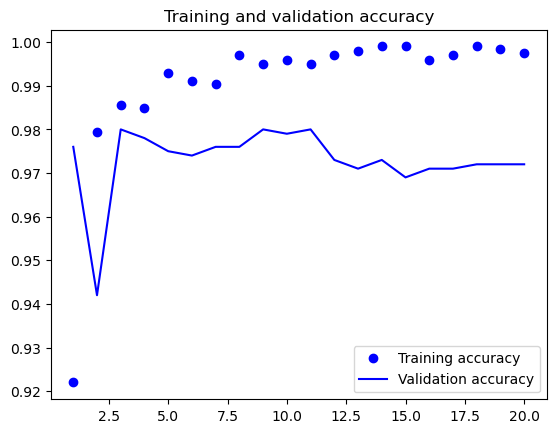

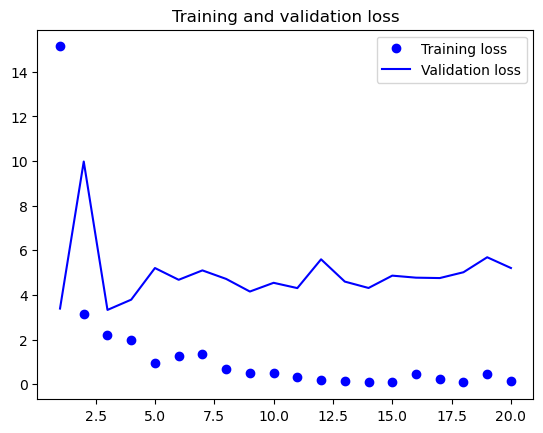

In [32]:
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

# Feature extraction together with data augmentation
Instantiating and freezing the VGG16 convolutional base

In [33]:
conv_base  = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)
conv_base.trainable = False

# Printing the list of trainable weights before and after freezing

In [34]:
conv_base.trainable = True
print("This is the number of trainable weights "
      "before freezing the conv base:", len(conv_base.trainable_weights))

This is the number of trainable weights before freezing the conv base: 26


In [35]:
conv_base.trainable = False
print("This is the number of trainable weights "
      "after freezing the conv base:", len(conv_base.trainable_weights))

This is the number of trainable weights after freezing the conv base: 0


# Adding a data augmentation stage and a classifier to the convolutional base

In [36]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [38]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_with_data_augmentation.x",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/50


2025-04-12 07:45:06.385876: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


 1/63 [..............................] - ETA: 1:37 - loss: 21.1044 - accuracy: 0.9062

2025-04-12 07:45:07.960375: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


 2/63 [..............................] - ETA: 57s - loss: 12.7292 - accuracy: 0.9062 

...

61/63 [============================>.] - ETA: 1s - loss: 0.2730 - accuracy: 0.9887

2025-04-12 08:58:43.903446: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


62/63 [============================>.] - ETA: 0s - loss: 0.2686 - accuracy: 0.9889

2025-04-12 08:58:44.786207: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


63/63 [==============================] - 85s 1s/step - loss: 0.2665 - accuracy: 0.9890 - val_loss: 1.0835 - val_accuracy: 0.9820


# Evaluating the model on the test set

In [39]:
test_model = keras.models.load_model(
    "feature_extraction_with_data_augmentation.x")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

2025-04-12 09:02:32.792075: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


63/63 [==============================] - 56s 868ms/step - loss: 0.7082 - accuracy: 0.9755
Test accuracy: 0.975


# Fine-tuning a pretrained 

In [40]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, None, None, 128)   0     

# Freezing all layers until the fourth from the last

In [41]:
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

# Fine-tuning the model

In [45]:
model.compile(loss="binary_crossentropy",
              optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.x",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30


2025-04-12 09:08:53.683061: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-04-12 09:08:54.504189: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


 1/63 [..............................] - ETA: 7:33 - loss: 3.0173e-06 - accuracy: 1.0000

2025-04-12 09:08:58.089359: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


 2/63 [..............................] - ETA: 1:42 - loss: 1.5087e-06 - accuracy: 1.0000

...

61/63 [============================>.] - ETA: 2s - loss: 0.0784 - accuracy: 0.9964

2025-04-12 10:00:27.301356: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


62/63 [============================>.] - ETA: 1s - loss: 0.0771 - accuracy: 0.9965

2025-04-12 10:00:28.525913: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


63/63 [==============================] - 107s 2s/step - loss: 0.0765 - accuracy: 0.9965 - val_loss: 0.6474 - val_accuracy: 0.9840


In [46]:
model = keras.models.load_model("fine_tuning.x")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

2025-04-12 10:02:59.717600: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


63/63 [==============================] - 57s 881ms/step - loss: 0.7860 - accuracy: 0.9755
Test accuracy: 0.975
